# Week 4: Transfer Learning, BERT (Homework)

## Question Search Engine

Embeddings are a good source of information for solving various tasks. For example, we can classify texts or find similar documents using their representations. We already know about word2vec, GloVe and fasttext, but they don't use context information from given text (only from contexts of source data).

For today we will use full power of context-aware embeddings to find text duplicates!

__Warning:__ this task assumes you have seen `seminar.ipynb`!

In [1]:
# %pip install --upgrade transformers datasets accelerate deepspeed
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
import datasets
import tqdm

### Data Preparation

In [2]:
qqp = datasets.load_dataset("SetFit/qqp")
print("\n")
print("Sample[0]:", qqp["train"][0])
print("Sample[3]:", qqp["train"][3])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/313 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/70.8M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl:   0%|          | 0.00/76.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363846 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/40430 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/390965 [00:00<?, ? examples/s]



Sample[0]: {'text1': 'How is the life of a math student? Could you describe your own experiences?', 'text2': 'Which level of prepration is enough for the exam jlpt5?', 'label': 0, 'idx': 0, 'label_text': 'not duplicate'}
Sample[3]: {'text1': 'What can one do after MBBS?', 'text2': 'What do i do after my MBBS ?', 'label': 1, 'idx': 3, 'label_text': 'duplicate'}


In [3]:
model_name = "gchhablani/bert-base-cased-finetuned-qqp"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)
model = transformers.AutoModelForSequenceClassification.from_pretrained(model_name)

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: gchhablani/bert-base-cased-finetuned-qqp
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
MAX_LENGTH = 128

def preprocess_function(examples):
    result = tokenizer(
        examples["text1"],
        examples["text2"],
        padding="max_length",
        max_length=MAX_LENGTH,
        truncation=True,
    )

    result["label"] = examples["label"]

    return result

In [5]:
qqp_preprocessed = qqp.map(preprocess_function, batched=True)

Map:   0%|          | 0/363846 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Map:   0%|          | 0/40430 [00:00<?, ? examples/s]

Map:   0%|          | 0/390965 [00:00<?, ? examples/s]

In [6]:
print(repr(qqp_preprocessed["train"][0]["input_ids"])[:100], "...")

[101, 1731, 1110, 1103, 1297, 1104, 170, 12523, 2377, 136, 7426, 1128, 5594, 1240, 1319, 5758, 136,  ...


### Evaluation (1 point)

We randomly chose a model trained on QQP - but is it any good?

One way to measure this is with validation accuracy - which is what you will implement next.

Here's the interface to help you do that:

In [2]:
device = torch.device('cuda')

In [8]:
model.to(device);

In [9]:
val_set = qqp_preprocessed["validation"]
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=1, shuffle=False, collate_fn=transformers.default_data_collator
)

In [10]:
@torch.no_grad()
def evaluate_accuracy(model, val_loader, device):
    model.eval()
    total, correct = 0, 0
    for batch in tqdm.tqdm(val_loader):
      predicted = model(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device),
        token_type_ids=batch["token_type_ids"].to(device),
      )
      predicted_labels = predicted.logits.argmax(dim=-1).cpu()
      true_labels = batch['labels'].cpu()
      correct += (true_labels == predicted_labels).sum()
      total += len(true_labels)
    return correct / total

**Task 1 (1 point)**

- Measure the validation accuracy of your model. Doing so naively may take several hours. Please make sure you use the following optimizations:
  - Run the model on GPU with no_grad
  - Using batch size larger than 1
  - Use optimize data loader with num_workers > 1
  - (Optional) Use [mixed precision](https://pytorch.org/docs/stable/notes/amp_examples.html)


In [25]:
val_set = qqp_preprocessed["validation"]
val_loader = torch.utils.data.DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=transformers.default_data_collator, num_workers=2)

accuracy = evaluate_accuracy(model, val_loader, device)

100%|██████████| 1264/1264 [04:54<00:00,  4.30it/s]


In [26]:
assert 0.9 < accuracy < 0.91

### Training (4 points)

For this task, you have two options:

__Option A:__ fine-tune your own model. You are free to choose any model __except for the original BERT.__ We recommend [DeBERTa-v3](https://huggingface.co/microsoft/deberta-v3-base). Better yet, choose the best model based on public benchmarks (e.g. [GLUE](https://gluebenchmark.com/)).

You can write the training code manually or use transformers.Trainer (see [this example](https://github.com/huggingface/transformers/blob/main/examples/pytorch/text-classification)). Please make sure that your model's accuracy is at least __comparable__ with the above example for BERT.


__Option B:__ compare at least 3 pre-finetuned models (in addition to the above BERT model). For each model, report (1) its accuracy, (2) its speed, measured in samples per second in your hardware setup and (3) its size in megabytes. Please take care to compare models in equal setting, e.g. same CPU / GPU. Compile your results into a table and write a short (~half-page on top of a table) report, summarizing your findings.

**Task 2 (4 points)**
- Choose Option A or Option B (only one will be graded)
- Follow all the instructions and restrictions

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, TrainingArguments, Trainer
from transformers.modeling_outputs import SequenceClassifierOutput

ds = load_dataset("SetFit/qqp")

class DuplicateDataCollator:
    def __init__(self, model_name="microsoft/deberta-v3-base", max_length=256, with_labels=True):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        self.max_length = max_length
        self.with_labels = with_labels

    def __call__(self, examples):
        text1 = [ex["text1"] for ex in examples]
        text2 = [ex["text2"] for ex in examples]

        tok1 = self.tokenizer(text1, padding=True, truncation=True, max_length=self.max_length, return_tensors="pt")
        tok2 = self.tokenizer(text2, padding=True, truncation=True, max_length=self.max_length, return_tensors="pt")

        batch = {
            "input_ids1": tok1["input_ids"],
            "attention_mask1": tok1["attention_mask"],
            "input_ids2": tok2["input_ids"],
            "attention_mask2": tok2["attention_mask"],
        }

        if self.with_labels and "label" in examples[0]:
            batch["labels"] = torch.tensor([ex["label"] for ex in examples], dtype=torch.float)
        if "idx" in examples[0]:
            batch["idx"] = torch.tensor([ex["idx"] for ex in examples], dtype=torch.long, )

        return batch

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

class DuplicateModel(nn.Module):
    def __init__(self, model_name="microsoft/deberta-v3-base", hidden=64, dropout=0.1, freeze_backbone=True, pos_weight=None):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        dim = self.backbone.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(dim * 4, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

        if pos_weight is None:
            pos_weight = torch.tensor([1.0], dtype=torch.float)
        self.register_buffer("pos_weight", pos_weight)
        self.loss_fn = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

    def encode(self, input_ids, attention_mask):
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        return mean_pooling(out.last_hidden_state, attention_mask)

    def forward(self, input_ids1=None, attention_mask1=None, input_ids2=None, attention_mask2=None, labels=None, idx=None):
        # self.backbone.eval()
        u = self.encode(input_ids1, attention_mask1)
        v = self.encode(input_ids2, attention_mask2)
        u = torch.nn.functional.normalize(u, p=2, dim=1)
        v = torch.nn.functional.normalize(v, p=2, dim=1)

        feats = torch.cat([u, v, torch.abs(u - v), u * v], dim=1)
        feats = feats.float()
        logits = self.classifier(feats).squeeze(-1)

        loss = None
        if labels is not None:
            labels = labels.to(logits.dtype)
            loss = self.loss_fn(logits, labels)

        return SequenceClassifierOutput(loss=loss, logits=logits.unsqueeze(-1))


def compute_metrics(eval_pred):
    logits = eval_pred.predictions.reshape(-1)
    labels = eval_pred.label_ids.reshape(-1)
    probs = 1 / (1 + np.exp(-logits))

    best = {"f1": -1, "thr": 0.5, "acc": 0.0}
    for thr in np.linspace(0.05, 0.95, 181):
        preds = (probs >= thr).astype(np.int32)

        tp = ((preds == 1) & (labels == 1)).sum()
        fp = ((preds == 1) & (labels == 0)).sum()
        fn = ((preds == 0) & (labels == 1)).sum()
        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)

        acc = (preds == labels).mean()
        if f1 > best["f1"]:
            best = {"f1": float(f1), "thr": float(thr), "acc": float(acc)}

    return {"accuracy": best["acc"], "f1": best["f1"], "thr": best["thr"]}

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
model_name = "microsoft/deberta-v3-base"
model = DuplicateModel(model_name=model_name, hidden=64, dropout=0.1, freeze_backbone=True, pos_weight=torch.tensor([1.7]))
model.to(device)
data_collator = DuplicateDataCollator(model_name=model_name, max_length=256, with_labels=True)

args = TrainingArguments(
    output_dir="deberta_biencoder_qqp_frozen",
    learning_rate=1e-3,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    num_train_epochs=2,
    weight_decay=0.001,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    remove_unused_columns=False,
    logging_steps=600,
    save_steps=600,
    warmup_steps=300
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds["train"],
    eval_dataset=ds["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1,Thr
600,0.832195,0.805664,0.584418,0.585872,0.395000
1200,0.801368,0.795209,0.601682,0.594399,0.395000
1800,0.791048,0.786704,0.605442,0.599156,0.455000
2400,0.785147,0.781345,0.604180,0.601291,0.440000
3000,0.779729,0.777309,0.603710,0.602964,0.405000
3600,0.774288,0.773968,0.609325,0.605864,0.420000
4200,0.768229,0.772571,0.601583,0.606719,0.390000
4800,0.769481,0.770934,0.612689,0.607750,0.420000
5400,0.768556,0.770034,0.606629,0.608892,0.425000


TrainOutput(global_step=5686, training_loss=0.7848866288610801, metrics={'train_runtime': 2301.4056, 'train_samples_per_second': 316.195, 'train_steps_per_second': 2.471, 'total_flos': 0.0, 'train_loss': 0.7848866288610801, 'epoch': 2.0})

### Очень плохо, попробуем другой варинат!!!

##### Попробуем получать эмбеддинги из большой модели, а после чего обрабатывать их классификатором

##### Постороим датасет эмбеддингов

In [3]:
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
emb_model.to(device);

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

In [12]:
import numpy as np
from datasets import Dataset

def build_embedding_dataset_unique(emb_model, dataset, text1_col="text1", text2_col="text2", label_col="label", keep_cols=("idx",), batch_size=256, device=None, normalize=True, dtype=np.float16):
    all_texts = list(dataset[text1_col]) + list(dataset[text2_col])
    uniq_texts = list(dict.fromkeys(all_texts))

    uniq_embs = emb_model.encode(uniq_texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True, device=device, normalize_embeddings=normalize).astype(dtype)

    text2emb = {t: e for t, e in zip(uniq_texts, uniq_embs)}

    emb1 = np.stack([text2emb[t] for t in dataset[text1_col]])
    emb2 = np.stack([text2emb[t] for t in dataset[text2_col]])

    out = {
        "emb1": emb1,
        "emb2": emb2,
        "label": np.array(dataset[label_col], dtype=np.int64),
    }
    for c in keep_cols:
        if c in dataset.column_names:
            out[c] = dataset[c]

    return Dataset.from_dict(out)

In [29]:
train_set = build_embedding_dataset_unique(emb_model, qqp['train'], device=device, keep_cols=("idx", "text1", "text2"))
val_set = build_embedding_dataset_unique(emb_model, qqp['validation'], device=device, keep_cols=("idx", "text1", "text2"))

Batches:   0%|          | 0/1930 [00:00<?, ?it/s]

Batches:   0%|          | 0/287 [00:00<?, ?it/s]

In [32]:
# train_set.save_to_disk("/content/drive/MyDrive/Colab Notebooks/data/train_emb_ds")
# val_set.save_to_disk("/content/drive/MyDrive/Colab Notebooks/data/val_emb_ds")

Saving the dataset (0/4 shards):   0%|          | 0/363846 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/40430 [00:00<?, ? examples/s]

In [5]:
from datasets import load_from_disk

train_set = load_from_disk('/content/drive/MyDrive/Colab Notebooks/data/train_emb_ds')
val_set = load_from_disk('/content/drive/MyDrive/Colab Notebooks/data/val_emb_ds')

#### Класс модели и датасета

In [6]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, hf_ds):
        super().__init__()
        self.hf_ds = hf_ds

    def __getitem__(self, idx):
        sample = self.hf_ds[idx]
        return torch.tensor(sample['emb1']), torch.tensor(sample['emb2']), torch.tensor(sample['label'], dtype=torch.float32)

    def __len__(self):
        return len(self.hf_ds)

class Classifier(nn.Module):
    def __init__(self, emb_dim, hidden=(512, 256), dropout=0.1):
        super().__init__()
        layers = []
        prev = 1 + 2 * emb_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers += [nn.Linear(prev, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, emb1, emb2):
        cos = (emb1 * emb2).sum(dim=1, keepdim=True)
        x = torch.cat([cos, (emb1 - emb2).abs(), emb1 * emb2], dim=1)
        return self.net(x).squeeze(-1)

##### Обучающие и вспомогательные функции

In [7]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
from typing import Optional, Dict, List
import numpy as np

def find_best_threshold_f1(probs: np.ndarray, y_true: np.ndarray, grid_size: int = 181):
    y_true = y_true.astype(int)
    thresholds = np.linspace(0.05, 0.95, grid_size)

    best_f1, best_t = -1.0, 0.5
    best_p, best_r = 0.0, 0.0

    for t in thresholds:
        pred = (probs >= t).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        fn = np.sum((pred == 0) & (y_true == 1))

        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)

        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
            best_p, best_r = float(precision), float(recall)

    return best_t, best_f1, best_p, best_r

def training_epoch(model: torch.nn.Module, optimizer: torch.optim.Optimizer, criterion: torch.nn.Module, train_loader: torch.utils.data.DataLoader, device: torch.device, tqdm_desc="Train", max_grad_norm=None, threshold=0.5):
    model.train()
    loss_sum, n_samples, correct_sum = 0.0, 0, 0

    pbar = tqdm.tqdm(train_loader, desc=tqdm_desc)
    for emb1, emb2, y in pbar:
        emb1 = emb1.to(device).float()
        emb2 = emb2.to(device).float()
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(emb1, emb2)
        loss = criterion(logits, y)

        loss.backward()
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        bs = y.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= threshold).long()
            correct_sum += (preds == y.long()).sum().item()

        avg_loss = loss_sum / max(1, n_samples)
        avg_acc = correct_sum / max(1, n_samples)
        pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}", "thr": f"{threshold:.2f}"})

    return {"loss": loss_sum / max(1, n_samples), "acc": correct_sum / max(1, n_samples)}


@torch.no_grad()
def validation_epoch(model: torch.nn.Module, criterion: torch.nn.Module, valid_loader: torch.utils.data.DataLoader, device: torch.device, tqdm_desc="Valid", threshold=0.5, return_probs=True):
    model.eval()
    loss_sum, n_samples, correct_sum = 0.0, 0, 0

    all_probs = []
    all_y = []

    pbar = tqdm.tqdm(valid_loader, desc=tqdm_desc)
    for emb1, emb2, y in pbar:
        emb1 = emb1.to(device).float()
        emb2 = emb2.to(device).float()
        y = y.to(device).float()

        logits = model(emb1, emb2)
        loss = criterion(logits, y)

        bs = y.size(0)
        loss_sum += float(loss.item()) * bs
        n_samples += bs

        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        correct_sum += (preds == y.long()).sum().item()

        if return_probs:
            all_probs.append(probs.detach().cpu())
            all_y.append(y.detach().cpu())

        avg_loss = loss_sum / max(1, n_samples)
        avg_acc = correct_sum / max(1, n_samples)
        pbar.set_postfix({"loss": f"{avg_loss:.4f}", "acc": f"{avg_acc:.4f}", "thr": f"{threshold:.2f}"})

    out = {"loss": loss_sum / max(1, n_samples), "acc": correct_sum / max(1, n_samples)}

    if return_probs:
        out["probs"] = torch.cat(all_probs).numpy()
        out["y_true"] = torch.cat(all_y).numpy()

    return out

def plot_metrics(train_losses, val_losses, train_acc, val_acc, thresholds):
    clear_output(True)
    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_losses, marker="o", label="Train Loss")
    plt.plot(epochs, val_losses, marker="o", label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_acc, marker="o", label="Train Acc")
    plt.plot(epochs, val_acc, marker="o", label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, thresholds, marker="o")
    plt.xlabel("Epoch"); plt.ylabel("Threshold"); plt.title("Chosen threshold (val, by F1)")
    plt.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

def save_checkpoint(path: str, model: torch.nn.Module, optimizer: torch.optim.Optimizer, epoch: int, best_val_loss: float, best_thr: float) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    ckpt = {
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "best_threshold": best_thr,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
    }
    torch.save(ckpt, path)


def fit(model: torch.nn.Module, train_loader: torch.utils.data.DataLoader, val_loader: torch.utils.data.DataLoader, optimizer: torch.optim.Optimizer, criterion: torch.nn.Module, device: torch.device, num_epochs: int, scheduler: Optional[object] = None, out_dir: str = "models", plot_fn=None, max_grad_norm=None, threshold_grid_size: int = 181) -> Dict[str, List[float]]:
    model.to(device)
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_precision": [],
        "val_recall": [],
        "threshold": [],
        "lr": [],
    }

    best_val_loss = float("inf")
    best_path = os.path.join(out_dir, "best.pt")
    os.makedirs(out_dir, exist_ok=True)

    current_thr = 0.5

    for epoch in range(1, num_epochs + 1):
        tr = training_epoch(model=model, train_loader=train_loader, optimizer=optimizer, criterion=criterion, device=device, tqdm_desc=f"Train {epoch}/{num_epochs}", max_grad_norm=max_grad_norm, threshold=current_thr)

        va_raw = validation_epoch(model=model, valid_loader=val_loader, criterion=criterion, device=device, tqdm_desc=f"Valid {epoch}/{num_epochs}", threshold=current_thr, return_probs=True)

        best_thr, best_f1, best_p, best_r = find_best_threshold_f1(probs=va_raw["probs"], y_true=va_raw["y_true"], grid_size=threshold_grid_size)

        va = validation_epoch(model=model, valid_loader=val_loader, criterion=criterion, device=device, tqdm_desc=f"Valid(re-thr) {epoch}/{num_epochs}", threshold=best_thr, return_probs=False)

        current_thr = best_thr
        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(tr["loss"])
        history["train_acc"].append(tr["acc"])
        history["val_loss"].append(va["loss"])
        history["val_acc"].append(va["acc"])
        history["val_f1"].append(best_f1)
        history["val_precision"].append(best_p)
        history["val_recall"].append(best_r)
        history["threshold"].append(best_thr)
        history["lr"].append(lr)

        if scheduler is not None:
            try:
                scheduler.step(va["loss"])
            except TypeError:
                scheduler.step()

        save_checkpoint(os.path.join(out_dir, f"epoch_{epoch:03d}.pt"), model, optimizer, epoch, best_val_loss, best_thr)

        is_best = va["loss"] < best_val_loss
        if is_best:
            best_val_loss = va["loss"]
            save_checkpoint(best_path, model, optimizer, epoch, best_val_loss, best_thr)

        print(
            f"[{epoch:02d}/{num_epochs}] "
            f"train: loss={tr['loss']:.4f}, acc={tr['acc']:.4f} | "
            f"val: loss={va['loss']:.4f}, acc={va['acc']:.4f}, "
            f"f1={best_f1:.4f}, p={best_p:.4f}, r={best_r:.4f}, thr={best_thr:.3f} | "
            f"lr={lr:.2e} | best_val_loss={best_val_loss:.4f}"
        )

        if plot_fn is not None:
            plot_fn(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"], history["threshold"])

    return history

In [14]:
train_dataset = PairDataset(train_set)
val_dataset = PairDataset(val_set)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=512, shuffle=True, pin_memory=True, num_workers=8, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=512, shuffle=False, pin_memory=True, num_workers=8, persistent_workers=True)

In [15]:
model = Classifier(emb_dim=1024)
device = torch.device('cuda')
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.0001)

N_neg = len(train_set) - np.sum(train_set['label'])
N_pos = len(train_set) - N_neg

pos_weight = torch.tensor([N_neg / N_pos], device=device, dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
num_epochs = 10

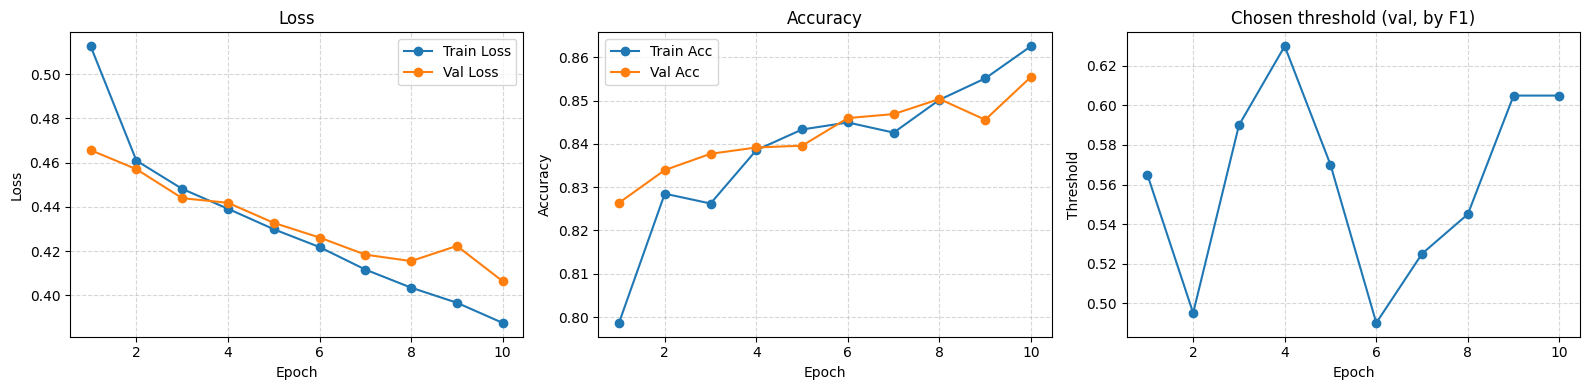

In [16]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=num_epochs,
    plot_fn=plot_metrics
)

### Finding Duplicates (1 point)

Finally, it is time to use your model to find duplicate questions.
Please implement a function that takes a question and finds top-5 potential duplicates in the training set. For now, it is fine if your function is slow, as long as it yields correct results.

Showcase how your function works with at least 5 examples.

**Task 3 (1 point)**
- Implement function for finding duplicates
- Test it on several examples (at least 5)
- Check suggested duplicates and make a conclusion about model correctness

In [ ]:
textToEmb = {} # соберем текста в ондом месте
for s in train_set:
    if s['text1'] not in textToEmb:
        textToEmb[s['text1']] = s['emb1']
    if s['text2'] not in textToEmb:
        textToEmb[s['text2']] = s['emb2']

In [50]:
@torch.no_grad()
def find_5_closest(emb_model, classifier, text, device):
    embedding = emb_model.encode(text, convert_to_numpy=True, device=device, normalize_embeddings=True)
    embedding = torch.tensor(embedding, device=device, dtype=torch.float32)
    top5 = []
    classifier.to(device)
    classifier.eval()
    for text, emb in tqdm.tqdm(textToEmb.items()):
        logit = classifier(embedding.unsqueeze(dim=0), torch.tensor(emb, device=device, dtype=torch.float32).unsqueeze(dim=0)).item()
        top5.append([text, logit])
        if len(top5) > 100000:
            top5 = sorted(top5, reverse=True, key=lambda x: x[1])[:5]
    top5 = sorted(top5, reverse=True, key=lambda x: x[1])[:5]
    return {t : float(1 / (1 + np.exp(-l))) for (t, l) in top5}

In [32]:
classifier = Classifier(emb_dim=1024)
classifier.load_state_dict(torch.load('/content/models/epoch_008.pt')['model_state'])

<All keys matched successfully>

In [33]:
emb_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [51]:
find_5_closest(emb_model, classifier, 'Is there a reason why we should travel alone?', device)

100%|██████████| 493874/493874 [04:33<00:00, 1807.90it/s]


{'Is there a reason why we should travel alone?': 0.9924532624238238,
 'Why should I travel alone?': 0.9378555100228836,
 'What are some reasons to travel alone?': 0.8975260216172942,
 'Why do people like to travel alone?': 0.8714628168920258,
 'Why do some people like traveling alone?': 0.7902011003966527}

In [53]:
find_5_closest(emb_model, classifier, 'How can I expand my IQ?', device)

100%|██████████| 493874/493874 [04:40<00:00, 1762.23it/s]


{'How can I expand my IQ?': 0.9849564805627501,
 'What can I do to increase my IQ?': 0.9324942175678377,
 'How can I increase my intelligence as much as possible?': 0.9200058266676311,
 'What are some things I can do to increase my IQ?': 0.9196885228089741,
 'How can I increase my IQ?': 0.9164425478125168}

In [62]:
find_5_closest(emb_model, classifier, 'What else should I do to quit smoking?', device)

100%|██████████| 493874/493874 [04:36<00:00, 1785.04it/s]


{'What else should I do to quit smoking?': 0.990701876348798,
 'How can I stop smoking?': 0.9515422570629783,
 'How can I quit smoking, right now?': 0.9382111876518348,
 'What are some ways to quit smoking?': 0.9334147648164393,
 'What are the best ways to quit chewing tobacco?': 0.929438980949437}

In [78]:
find_5_closest(emb_model, classifier, 'Which is better, mechanical engineering or computer science?', device)

100%|██████████| 493874/493874 [04:34<00:00, 1799.67it/s]


{'Which one is better: mechanical engineering or computer science?': 0.9710772085533448,
 'Which one is better: computer engineering vs computer science?': 0.8791056739013007,
 'Is computer science or mechanical engineering better for the future?': 0.8531235510214317,
 'Which is better: mechanical or computer science?': 0.7970712595012042,
 'My friend said computer science is way better than mechanical engineering. Is this true?': 0.7700498194291775}

In [86]:
find_5_closest(emb_model, classifier, 'Do you think I will ever get a girlfriend or attract any women? Im a 20 year old virgin and I might end up single for life because I been call ugly?', device)

100%|██████████| 493874/493874 [04:38<00:00, 1771.44it/s]


{'IM VERY UGLY, WILL I ever HAVE A GIRLFRIEND OR DIE ALONE? IM 20 YEARS OLD': 0.47186477850049635,
 "No woman wants to date me. I'm a 25-year-old kissless virgin. What should I do?": 0.39090511052209254,
 "I have never had a girlfriend or had an actual date with a girl and I'm 20 years old. I'm not ugly and not to bad on fat, Any help with my problem?": 0.37198025913312155,
 'Why am I still single at the age of 20 as a male? Im too ugly?': 0.3060467058452358,
 "I'm a 19 y/o male virgin who's never had a girlfriend, kissed, or dated. What should I do?": 0.23462861015319436}

### Bonus: Finding Duplicates Faster (0.5 point)

Try to find a way to run the function faster than just passing over all questions in a loop. For isntance, you can form a short-list of potential candidates using a cheaper method, and then run your tranformer on that short list. If you opted for this solution, please keep both the original implementation and the optimized one - and explain briefly what is the difference there.

**Bonus Task 1 (0.5 point)**
- Speed up your implementation from "Finding Duplicates" part
- Capture both old and new implementation work time
- Describe your approach

In [136]:
@torch.no_grad()
def find_5_closest_faster(emb_model, classifier, text, all_texts, all_embedds, device):
    embedding = emb_model.encode(text, convert_to_numpy=True, device=device, normalize_embeddings=True)
    embedding = torch.tensor(embedding, device=device, dtype=torch.float32)
    cos = (all_embedds * embedding).sum(dim=1)

    candidates_ids = torch.argsort(cos, descending=True, dim=0)[:1000]
    candidates = all_embedds[candidates_ids]

    # embedding = embedding.expand(10, -1)
    logits = classifier(embedding, candidates)

    top5_ids = candidates_ids[torch.argsort(logits, descending=True, dim=0)[:5]]

    scores = logits[torch.argsort(logits, descending=True, dim=0)[:5]].cpu().numpy().tolist()
    top5_texts = all_texts[top5_ids.cpu().numpy()].tolist()

    return {t : float(1 / (1 + np.exp(-s))) for t, s in zip(top5_texts, scores)}

In [123]:
all_embedds = torch.tensor(list(textToEmb.values()), dtype=torch.float32, device=device)
all_texts = np.array(list(textToEmb.keys()))

In [139]:
find_5_closest_faster(emb_model, classifier, 'Is there a reason why we should travel alone?', all_texts, all_embedds, device), find_5_closest_faster(emb_model, classifier, 'How can I expand my IQ?', all_texts, all_embedds, device), find_5_closest_faster(emb_model, classifier, 'What else should I do to quit smoking?', all_texts, all_embedds, device)

({'Is there a reason why we should travel alone?': 0.9924532552810055,
  'Why should I travel alone?': 0.9378555378141644,
  'What are some reasons to travel alone?': 0.8975259996892053,
  'Why do people like to travel alone?': 0.8714627901854767,
  'Why do some people like traveling alone?': 0.7902011003966527},
 {'How can I expand my IQ?': 0.9849564734973512,
  'What can I do to increase my IQ?': 0.9324942025596843,
  'How can I increase my intelligence as much as possible?': 0.9200058091211888,
  'What are some things I can do to increase my IQ?': 0.9196885228089741,
  'How can I increase my IQ?': 0.9164425295554681},
 {'What else should I do to quit smoking?': 0.990701876348798,
  'How can I stop smoking?': 0.9515422350762077,
  'How can I quit smoking, right now?': 0.9382111600091236,
  'What are some ways to quit smoking?': 0.9334147944526454,
  'What are the best ways to quit chewing tobacco?': 0.929438980949437})

### Bonus: Finding Duplicates in Old-Fashioned way (1.5 points)

In this bonus task you are supposed to use pretrained embeddings (word2vec, GloVe or fasttext) for solving the duplicates problem.

**Bonus Task 2 (1.5 points)**
- Solve Finding Duplicates problem using mentioned embeddings
- Compare old-fashioned solution to previous ones (quality, speed, etc.)
- Make a small report (up to 5 steps, results and conclusions) on work done in this part

In [142]:
import fasttext
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(repo_id="facebook/fasttext-en-vectors", filename="model.bin")
model = fasttext.load_model(model_path)

model.bin:   0%|          | 0.00/7.24G [00:00<?, ?B/s]

In [149]:
# получим эмбеддинги текстов
text2embFastText = {}
for text in tqdm.tqdm(textToEmb.keys()):
    text2embFastText[text] = model[text]

100%|██████████| 493874/493874 [00:17<00:00, 28947.37it/s]


In [150]:
all_texts = np.array(list(text2embFastText.keys()))
all_embedds = np.array(list(text2embFastText.values()))

In [185]:
def find_5_closest_fasttext(model, all_texts, all_embedds, text):
    embedd = model[text]
    cos = np.dot(all_embedds, embedd) / (np.linalg.norm(all_embedds, axis=1) * np.linalg.norm(embedd))
    return {t : s for t, s in zip(all_texts[np.argsort(-cos)][:5].tolist(), cos[np.argsort(-cos)][:5].tolist())}

In [184]:
find_5_closest_fasttext(model, all_texts, all_embedds, 'How can I expand my IQ?'), find_5_closest_fasttext(model, all_texts, all_embedds, 'Is there a reason why we should travel alone?'), find_5_closest_fasttext(model, all_texts, all_embedds, 'What else should I do to quit smoking?'), find_5_closest_fasttext(model, all_texts, all_embedds, 'Do you think I will ever get a girlfriend or attract any women? Im a 20 year old virgin and I might end up single for life because I been call ugly?')

/tmp/ipython-input-467487275.py:3: RuntimeWarning: invalid value encountered in divide
  cos = np.dot(all_embedds, embedd) / (np.linalg.norm(all_embedds, axis=1) * np.linalg.norm(embedd))


({'How can I expand my IQ?': 1.0000001192092896,
  'How can I expand my IT knowledge?': 0.9106957912445068,
  'How can I expand my writing repertoire without going back to school?': 0.8208346962928772,
  'How can I expand my vocabulary, and improve my writing skills in English?': 0.8170309662818909,
  'How do I expand my networks?': 0.8150768876075745},
 {'Is there a reason why we should travel alone?': 1.0,
  'Is there a reason why nuclear bombs were only used on Japan and not on Germany?': 0.7091524004936218,
  'Is there a reason why it is beneficial to follow people or be followed on Quora?': 0.7010564804077148,
  'Is there a long-range wifi antenna that I can connect to via wifi as if it were a router?': 0.6995730400085449,
  'Is there a reason why Bucharest and Budapest sound really similar?': 0.6992155313491821},
 {'What else should I do to quit smoking?': 0.9999999403953552,
  'What did you do to quit smoking and drinking?': 0.8402539491653442,
  'When should I quit smoking to h